In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import os
import matplotlib as mpl
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.patches import Rectangle

mpl.rcParams.update({
        "text.usetex": True,
        "font.family": "serif",
        "text.latex.preamble": r"\usepackage{amsmath}"
    })

plt.rcParams.update({'font.size': 20, 'axes.titlesize': 24, 'axes.labelsize': 20, 'legend.fontsize': 14, 'xtick.labelsize': 20, 'ytick.labelsize': 20})

seasons = {
        "DJF": [12, 1, 2],
        "MAM": [3, 4, 5],
        "JJA": [6, 7, 8],
        "SON": [9, 10, 11]
    }

# Frozen water path

## 2018-2023 CCIC-ERA5

In [2]:
CCIC_TIWP = xr.open_dataset('/data/s5/users/lara/master_thesis/data/ccic/CCIC_TIWP_diurnal_climatology_2018_2023_utc.nc')
ERA5 = xr.open_dataset('/data/s5/users/lara/master_thesis/data/ERA5/ERA5_diurnal_climatology_2018_2023_utc.nc')

def seasonal_zonal_mean(ds,var):
    
    seasons = {
        "DJF": [12, 1, 2],
        "MAM": [3, 4, 5],
        "JJA": [6, 7, 8],
        "SON": [9, 10, 11]
    }

    seasonal_zonal_mean = []

    for season, months in seasons.items():
        ds_sel = ds.sel(month=months)
        ds_season = ds_sel.mean("month")
        ds_zonal = zonal_mean(ds_season,var)
        seasonal_zonal_mean.append(ds_zonal)
    
    seasonal_zonal_mean = xr.concat(seasonal_zonal_mean, dim='season')
    seasonal_zonal_mean = seasonal_zonal_mean.assign_coords(season=list(seasons.keys()))
    return seasonal_zonal_mean

def zonal_mean(ds,var):
    ds
    # select the variable
    ds = ds.where(ds[var]>=0)
    da = ds[var]
    # time mean
    da = da.mean("hour_of_day")

    # zonal mean (avg over longitudes)
    # try common names
    for lon_name in ["lon", "longitude"]:
        if lon_name in da.dims:
            da = da.mean(lon_name)
            break
    return da

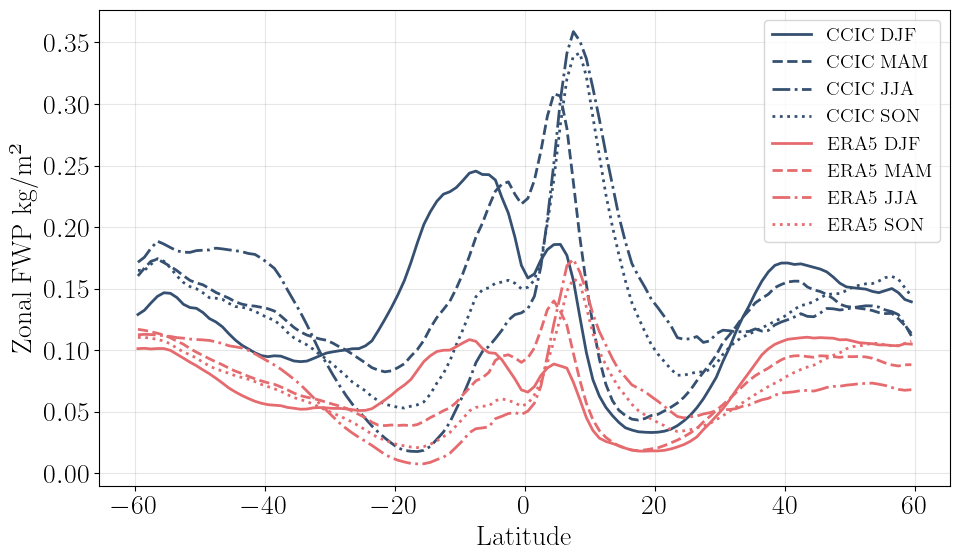

In [3]:
seasonal_zonal_mean_ccic = seasonal_zonal_mean(CCIC_TIWP, 'tiwp')
seasonal_zonal_mean_era5 = seasonal_zonal_mean(ERA5, 'tiwp')

ccic_color = '#355070'  
era5_color = '#e56b6fff'

seasons = {
        "DJF": [12, 1, 2],
        "MAM": [3, 4, 5],
        "JJA": [6, 7, 8],
        "SON": [9, 10, 11]
    }

colors = {
        "CCIC": ccic_color,
        "ERA5": era5_color
    }

season_linestyles = ['-', '--', '-.', ':']
season_names = ['DJF', 'MAM', 'JJA', 'SON']

plt.figure(figsize=(10, 6))

for dataset, label in zip([seasonal_zonal_mean_ccic, seasonal_zonal_mean_era5], ["CCIC", "ERA5"]):
    for season in seasons.keys():
        da_season = dataset.sel(season=season)
        plt.plot(da_season['lat'], da_season, label=f"{label} {season}", color=colors[label], linestyle=season_linestyles[season_names.index(season)], linewidth=2)
    
plt.xlabel("Latitude")
plt.ylabel("Zonal FWP kg/m²")
#plt.title("Seasonal Zonal Mean Precipitation 2018-2023: IMERG vs ERA5")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('../pdf/zonal_mean_FWP_ERA5.pdf', bbox_inches='tight')
plt.tight_layout()

## 2018 - 2019 CCIC, ERA, 2C-ICE, DARDAR

In [4]:
ds = xr.open_dataset("/scratch/leko/ccic_record/data/processed/cloudsat_time_series.nc").sel(latitude = slice(-60,60))                  
ccic = xr.open_dataset('/data/s5/users/lara/master_thesis/data/ccic/CCIC_TIWP_diurnal_climatology_2018_2019_utc.nc')
era5 = xr.open_dataset('/data/s5/users/lara/master_thesis/data/ERA5/ERA5_diurnal_climatology_2018_2019_utc.nc')
ccic = ccic.tiwp.mean(dim = 'hour_of_day').mean(dim= 'lon')
ccic_seasons = []
for months in seasons.values():
    ccic_season = ccic.sel(month = months).mean('month')
    ccic_seasons.append(ccic_season)
ccic_seasons = xr.concat(ccic_seasons, dim = 'season')
ccic_seasons['season'] = list(seasons.keys())
era5 = era5.tiwp.mean(dim = 'hour_of_day').mean(dim= 'lon')
era5_seasons = []
for months in seasons.values():
    era5_season = era5.sel(month = months).mean('month')
    era5_seasons.append(era5_season)
era5_seasons = xr.concat(era5_seasons, dim = 'season')
era5_seasons['season'] = list(seasons.keys())
ds_sel = ds.sel(year = slice('2018-12-31T00:00:00.000000000', '2019-12-31T00:00:00.000000000'))
ds_mean = ds_sel.groupby('month').mean('time').mean('year')

In [5]:
ds_seasons = []
for months in seasons.values():
    ds_season = ds_mean.sel(month = months).mean('month')
    ds_seasons.append(ds_season)
ds_seasons = xr.concat(ds_seasons, dim = 'season')
ds_seasons['season'] = list(seasons.keys())
ds_seasons_zonal = ds_seasons.mean('longitude')

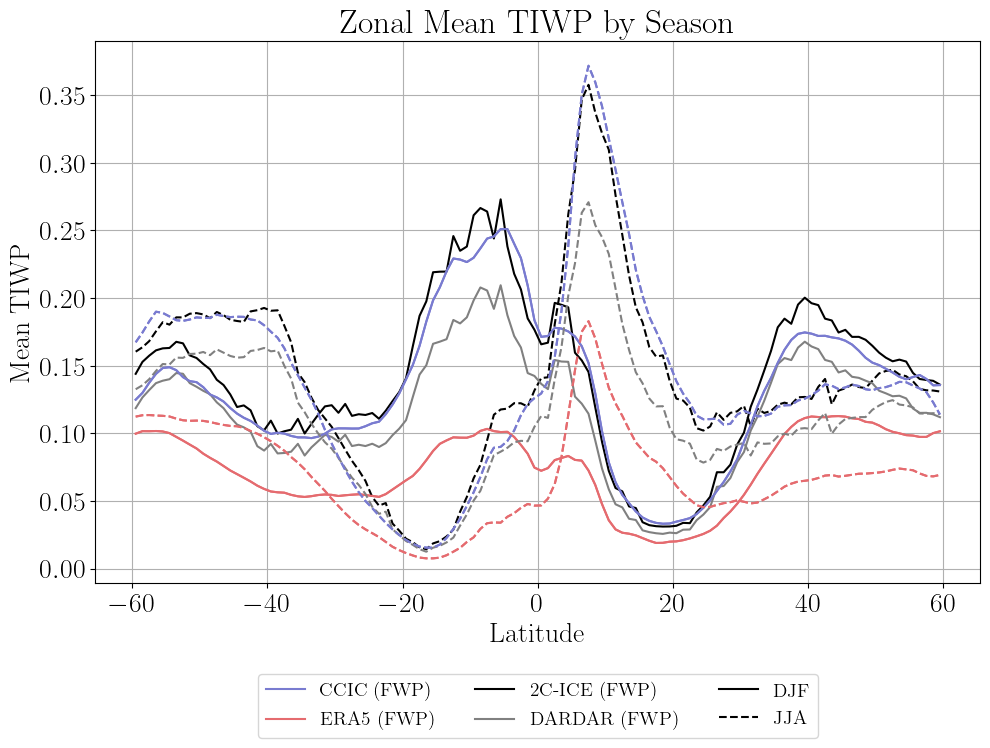

In [13]:
vars = ['tiwp_monthly_2cice', 'tiwp_monthly_dardar']
season_linestyles = ['-', '--']
season_names = ['DJF', 'JJA',]
ccic_color = '#797bd0'  
era5_color = '#e56b6fff'
ice_color = 'black'
dardar_color = 'grey'
colors = [ice_color, dardar_color]
plt.figure(figsize=(10, 8))
for i,var in enumerate(vars):
    data = ds_seasons_zonal[var]
    if var == 'tiwp_monthly_dardar':
        data = data.where(data < 1e3)
    for j, season in enumerate(['DJF', 'JJA']):
        plt.plot(ds_seasons_zonal['latitude'], data.sel(season=season), label=f'{var} - {season}', linestyle=season_linestyles[j], color=colors[i])
        plt.plot(ccic_seasons['lat'], ccic_seasons.sel(season=season), label=f'CCIC - {season}', linestyle=season_linestyles[j], color=ccic_color)
        plt.plot(era5_seasons['lat'], era5_seasons.sel(season=season), label=f'ERA5 - {season}', linestyle=season_linestyles[j], color=era5_color)

import matplotlib.lines as mlines
dataset_handles = [
    mlines.Line2D([], [], color = ccic_color, label='CCIC (FWP)'),
    mlines.Line2D([], [], color = era5_color, label='ERA5 (FWP)'),
    mlines.Line2D([], [], color = ice_color, label='2C-ICE (FWP)'),
    mlines.Line2D([], [], color = dardar_color, label='DARDAR (FWP)'),

]
season_handles = [
    mlines.Line2D([], [], color='black', linestyle=season_linestyles[i], label=season_names[i])
    for i in range(2)
 ]

plt.legend(dataset_handles + season_handles, [h.get_label() for h in dataset_handles + season_handles],
           loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=True)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.xlabel('Latitude')
plt.ylabel('Mean TIWP')
plt.title('Zonal Mean TIWP by Season')
plt.grid()
plt.savefig('../pdf/zonal_mean_TIWP_CLOUDSAT.pdf', bbox_inches='tight')
plt.show()
    

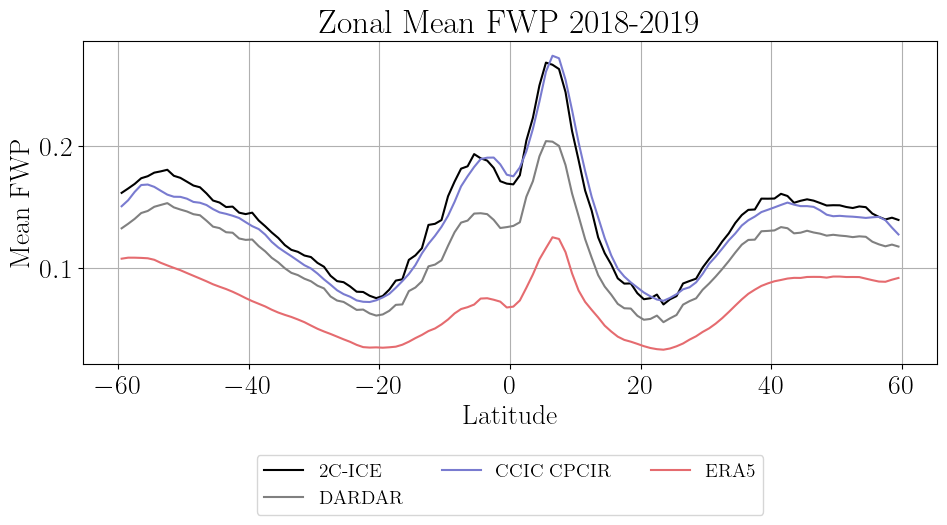

In [6]:
ccic_color = '#797bd0'
era5_color = '#e56b6fff'
ice_color = 'black'
dardar_color = 'grey'
colors = [ice_color, dardar_color]
labels = ['2C-ICE', 'DARDAR']
plt.figure(figsize=(10, 6))
for i,var in enumerate(vars):
    data = ds_seasons_zonal[var]
    if var == 'tiwp_monthly_dardar':
        data = data.where(data < 1e3)
    plt.plot(ds_seasons_zonal['latitude'], data.mean('season'), label=labels[i], color=colors[i])
plt.plot(ccic_seasons['lat'], ccic_seasons.mean('season'), label=f'CCIC CPCIR', color=ccic_color)
plt.plot(era5_seasons['lat'], era5_seasons.mean('season'), label=f'ERA5', color=era5_color)

plt.xlabel('Latitude')
plt.ylabel('Mean FWP')
plt.title('Zonal Mean FWP 2018-2019')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.25), ncol=3, frameon=True)
plt.tight_layout(rect=[0, 0, 1, 1])
plt.grid()
plt.show()

## Feb 2020, DYAMOND

In [7]:
CCIC = xr.open_dataset('/data/s5/users/lara/master_thesis/data/ccic/CCIC_diurnal_feb2020_utc.nc')
ERA5 = xr.open_dataset('/data/s5/users/lara/master_thesis/data/ERA5/ERA5_diurnal_feb2020_utc.nc')

MODELS = {
    "ARPEGE": xr.open_dataset('/data/s5/users/lara/master_thesis/data/DYAMOND/ARPEGE_diurnal_feb2020_utc.nc'),
    "GEOS": xr.open_dataset('/data/s5/users/lara/master_thesis/data/DYAMOND/GEOS_diurnal_feb2020_utc.nc'),
    "GSAM": xr.open_dataset('/data/s5/users/lara/master_thesis/data/DYAMOND/GSAM_diurnal_feb2020_utc.nc'), 
    "ICON": xr.open_dataset('/data/s5/users/lara/master_thesis/data/DYAMOND/ICON_diurnal_feb2020_utc.nc'),
    "IFS": xr.open_dataset('/data/s5/users/lara/master_thesis/data/DYAMOND/IFS_diurnal_feb2020_utc.nc'),
    "MPAS": xr.open_dataset('/data/s5/users/lara/master_thesis/data/DYAMOND/MPAS_diurnal_feb2020_utc.nc'),
    "GEM": xr.open_dataset('/data/s5/users/lara/master_thesis/data/DYAMOND/GEM_diurnal_feb2020_utc.nc'),
    'GFDL': xr.open_dataset('/data/s5/users/lara/master_thesis/data/DYAMOND/GFDL_diurnal_feb2020_utc.nc'),
    "GRIST": xr.open_dataset('/data/s5/users/lara/master_thesis/data/DYAMOND/GRIST_diurnal_feb2020_utc.nc')
}

In [8]:
var = 'tiwp'

CCIC_zonal = zonal_mean(CCIC,var)
ERA5_zonal = zonal_mean(ERA5,var)
zonal_models = {}
for model in MODELS:
    zonal_model = zonal_mean(MODELS[model],var)
    zonal_models[model] = zonal_model

    

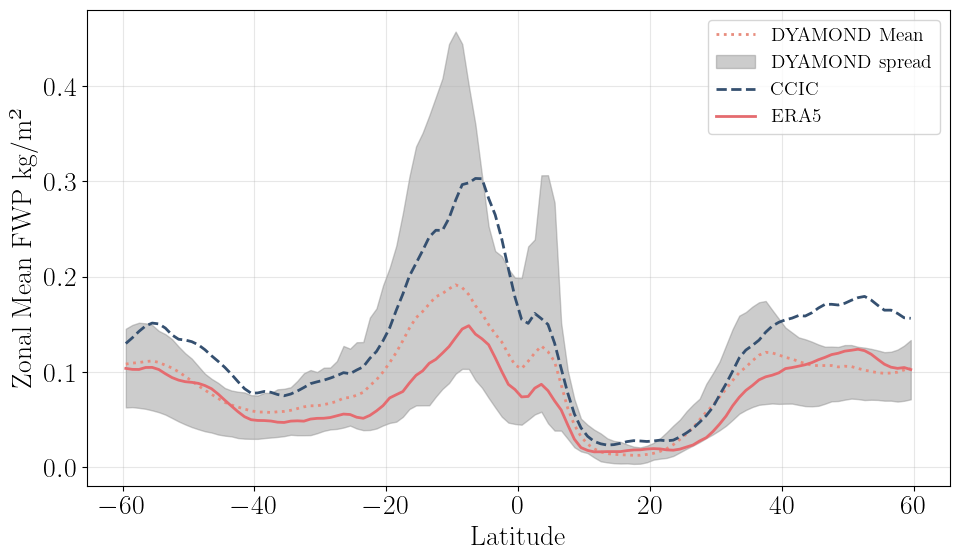

In [10]:
ccic_color = '#355070'  
era5_color = '#e56b6fff'
dyamond_color = '#E88C7D'
colors = [ccic_color, era5_color]
linestyles = ['--','-',':']


plt.figure(figsize=(10, 6))

# Load DYAMOND model data and compute spread
dyamond_lat = CCIC_zonal.lat
dyamond_vals = []
for label, data in zonal_models.items():
    fname = label
    dyamond_vals.append(data)
# Plot DYAMOND mean
dyamond_mean = np.mean(dyamond_vals, axis=0)
plt.plot(dyamond_lat, dyamond_mean, label='DYAMOND Mean', color=dyamond_color, linestyle=':', linewidth=2)
# # Plot all DYMOND models separately
# for idx, label in enumerate(zonal_models.keys()):
#     plt.plot(dyamond_lat, zonal_models[label], label=label, linestyle='--', linewidth=1)
# Plot DYAMOND spread as shaded area
if dyamond_vals:
    dyamond_vals = np.stack(dyamond_vals)
    dyamond_min = np.min(dyamond_vals, axis=0)
    dyamond_max = np.max(dyamond_vals, axis=0)
    plt.fill_between(dyamond_lat, dyamond_min, dyamond_max, color='gray', alpha=0.4, label='DYAMOND spread')

# Plot ERA5 and IMERG as lines
plt.plot(CCIC_zonal.lat, CCIC_zonal, label='CCIC', color=colors[0], linestyle=linestyles[0], linewidth=2)
plt.plot(ERA5_zonal.lat, ERA5_zonal, label='ERA5', color=colors[1], linestyle=linestyles[1], linewidth=2)

plt.xlabel("Latitude")
plt.ylabel("Zonal Mean FWP kg/m²")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('../pdf/zonal_mean_DYAMOND_FWP_ERA5.pdf', bbox_inches='tight')                                                          
plt.tight_layout()

# IMERG

In [23]:
def plot_Seasonal_zonal_means(dataset1, dataset2):

    # Define seasons
    seasons = {
        "DJF": [12, 1, 2],
        "MAM": [3, 4, 5],
        "JJA": [6, 7, 8],
        "SON": [9, 10, 11]
    }

    # Get latitude coordinate name
    lat_name = "lat" if "lat" in dataset1.coords else "latitude"

    # Colorblind-friendly colors (matplotlib tab10)
    imerg_color = '#6D597A'
    era5_color = '#e56b6fff'
    colors = {
        "IMERG": imerg_color,
        "ERA5": era5_color
    }
    season_linestyles = ['-', '--', '-.', ':']
    season_names = ['DJF', 'MAM', 'JJA', 'SON']


    plt.figure(figsize=(10, 6))

    for dataset, label in zip([dataset1, dataset2], ["IMERG", "ERA5"]):
        for season, months in seasons.items():
            # Select months, handle December (12) for DJF
            months_sel = months
            # For DJF, need to handle December from previous year
            if season == "DJF":
                da = dataset["pr"].sel(month=months_sel)
                # If December is not present, skip
                if 12 not in dataset["month"]:
                    da = da.sel(month=[m for m in months_sel if m != 12])
            else:
                da = dataset["pr"].sel(month=months_sel)
            # Mean over months
            da_season = da.mean("month")
            plt.plot(dataset[lat_name], da_season, label=f"{label} {season}", color=colors[label], linestyle=season_linestyles[season_names.index(season)], linewidth=2)

    plt.xlabel("Latitude")
    plt.ylabel("Zonal Mean Precipitation (mm/hr)")
    #plt.title("Seasonal Zonal Mean Precipitation 2018-2023: IMERG vs ERA5")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    return plt

def zonal_means_february(data_path, model_files):

    # DYAMOND models (excluding ERA5 and IMERG)
    dyamond_models = [k for k in model_files if k not in ["ERA5", "IMERG"]]


    imerg_color = '#6D597A'
    era5_color = '#e56b6fff'
    dyamond_color = '#E88C7D'
    colors = [imerg_color, era5_color]
    linestyles = ['--','-',':']


    plt.figure(figsize=(10, 6))

    # Load DYAMOND model data and compute spread
    dyamond_lat = None
    dyamond_vals = []
    for label in dyamond_models:
        fname = model_files[label]
        fpath = os.path.join(data_path, fname)
        if not os.path.exists(fpath):
            print(f"File not found: {fpath}")
            continue
        ds = xr.open_dataset(fpath)
        var = None
        for v in ds.data_vars:
            if "pr" in v or "precipitation" in v or "total_precipitation" in v:
                var = v
                break
        if var is None:
            var = list(ds.data_vars)[0]
        lat_name = "lat" if "lat" in ds.coords else "latitude"
        if dyamond_lat is None:
            dyamond_lat = ds[lat_name].values
        dyamond_vals.append(ds[var].values)
    # Plot DYAMOND mean
    dyamond_mean = np.mean(dyamond_vals, axis=0)
    plt.plot(dyamond_lat, dyamond_mean, label='DYAMOND Mean', color=dyamond_color, linestyle=':', linewidth=2)
    # Plot DYAMOND spread as shaded area
    if dyamond_vals:
        dyamond_vals = np.stack(dyamond_vals)
        dyamond_min = np.min(dyamond_vals, axis=0)
        dyamond_max = np.max(dyamond_vals, axis=0)
        plt.fill_between(dyamond_lat, dyamond_min, dyamond_max, color='gray', alpha=0.4, label='DYAMOND spread')

    # Plot ERA5 and IMERG as lines
    for idx, label in enumerate(["IMERG", "ERA5"]):
        fname = model_files[label]
        fpath = os.path.join(data_path, fname)
        if not os.path.exists(fpath):
            print(f"File not found: {fpath}")
            continue
        ds = xr.open_dataset(fpath)
        var = None
        for v in ds.data_vars:
            if "pr" in v or "precipitation" in v or "total_precipitation" in v:
                var = v
                break
        if var is None:
            var = list(ds.data_vars)[0]
        lat_name = "lat" if "lat" in ds.coords else "latitude"
        plt.plot(ds[lat_name], ds[var], label=label, color=colors[idx], linestyle=linestyles[idx], linewidth=2)

    plt.xlabel("Latitude")
    plt.ylabel("Zonal Mean Precipitation (mm/hr)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    return plt

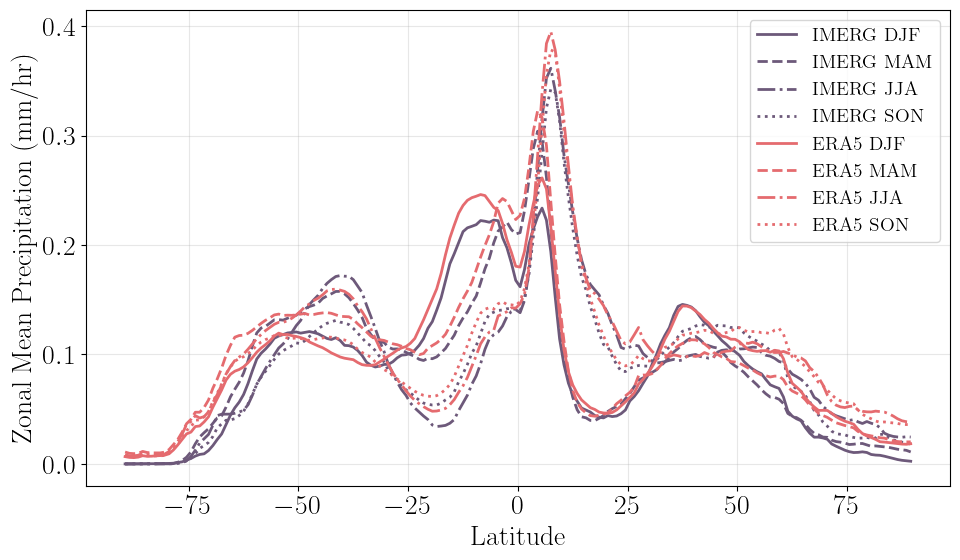

In [ ]:
# All-year zonal mean files

# Update file paths if needed
imerg_file = "/scratch/leko/zonal_means/all_months/IMERG_monthly.nc"
era5_file = "/scratch/leko/zonal_means/all_months/ERA5_monthly.nc"

# Open datasets
imerg = xr.open_dataset(imerg_file)
era5 = xr.open_dataset(era5_file)
plt = plot_Seasonal_zonal_means(imerg, era5)
plt.savefig('pdf/zonal_mean_IMERG_ERA5.pdf')
plt.show()

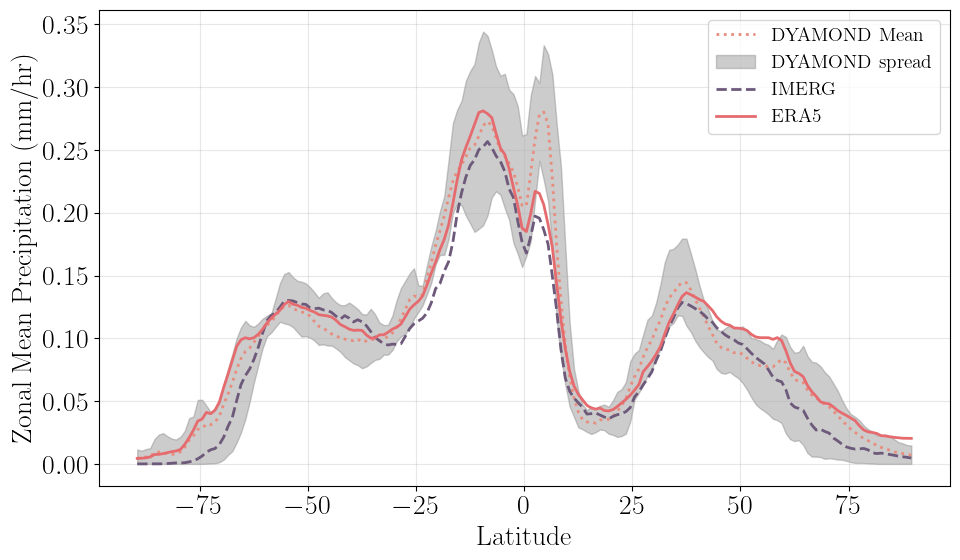

In [25]:
# Path to zonal mean files
data_path = "/scratch/leko/zonal_means/feb"

# List of models to plot (update names as needed)
model_files = {
    "ERA5": "ERA5.nc",
    "IMERG": "IMERG.nc",
    "ARPEGE": "ARPEGE.nc",
    "GEOS": "GEOS.nc",
    "gSAM": "gSAM.nc",
    "ICON": "ICON.nc",
    "IFS": "IFS.nc",
    "SHiELD": "SHiELD.nc"
}

plt = zonal_means_february(data_path, model_files)
plt.savefig('pdf/zonal_mean_DYAMOND_IMERG_ERA5_spread.pdf')
plt.show()